In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
# from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI

# from kaggle_secrets import UserSecretsClient
# user_secrets = UserSecretsClient()
# EMBEDDING_API_KEY = user_secrets.get_secret("API_KEY_1")
# LLM_API_KEY = user_secrets.get_secret("API_KEY_2")

# # 🤖 Loading Google GenAI Embeddings (using Key #1)
# print("Loading embedding 2 via Gemini API...")
# embedding_model = GoogleGenerativeAIEmbeddings(
#     model="models/gemini-embedding-2",
#     api_key=EMBEDDING_API_KEY
# )
# # 🤖 Loading Gemini LLM (using Key #2)
# print("Loading gemini-2.5-flash via Gemini API...")
# llm = ChatGoogleGenerativeAI(
#     model="gemini-2.5-flash",
#     temperature=2,
#     api_key=LLM_API_KEY
# )

# print("Models loaded successfully using isolated API keys!")

In [8]:
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_classic.retrievers import ParentDocumentRetriever
from langchain_core.stores import InMemoryStore
from langchain_core.output_parsers import StrOutputParser
from langgraph.checkpoint.sqlite import SqliteSaver

In [1]:
import urllib.request
import os 
import time
# 1. System dependencies for Ollama hardware detection
!apt-get update -qq && apt-get install -y -qq pciutils lshw zstd

# 2. Download and install the Ollama Linux binary
!curl -fsSL https://ollama.com/install.sh | sh

print("🚀 Starting Ollama server on the Kaggle GPU...")

# 3. Start the server detached in the background
os.system("nohup ollama serve > ollama.log 2>&1 &")

# 4. Wait for the server to wake up and start listening
for i in range(1, 15):
    try:
        response = urllib.request.urlopen("http://localhost:11434/", timeout=2)
        if response.getcode() == 200:
            print("✅ Ollama is awake and ready!")
            break
    except Exception:
        print(f"⏳ Waiting for server to initialize... (Attempt {i}/15)")
        time.sleep(2)
else:
    print("❌ Ollama failed to start. Check logs.")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package pci.ids.
(Reading database ... 125128 files and directories currently installed.)
Preparing to unpack .../0-pci.ids_0.0~2022.01.22-1ubuntu0.1_all.deb ...
Unpacking pci.ids (0.0~2022.01.22-1ubuntu0.1) ...
Selecting previously unselected package libpci3:amd64.
Preparing to unpack .../1-libpci3_1%3a3.7.0-6_amd64.deb ...
Unpacking libpci3:amd64 (1:3.7.0-6) ...
Selecting previously unselected package lshw.
Preparing to unpack .../2-lshw_02.19.git.2021.06.19.996aaad9c7-2ubuntu0.22.04.1_amd64.deb ...
Unpacking lshw (02.19.git.2021.06.19.996aaad9c7-2ubuntu0.22.04.1) ...
Selecting previously unselected package pciutils.
Preparing to unpack .../3-pciutils_1%3a3.7.0-6_amd64.deb ...
Unpacking pciutils (1:3.7.0-6) ...
Selecting previously unselected package usb.ids.
Prepari

In [2]:
print("📥 Downloading Qwen 14B and Nomic Embeddings (this will take a few minutes)...")
!ollama pull qwen2.5:32b
!ollama pull nomic-embed-text
print("🎉 All done! You are ready to run your RAG pipeline.")

📥 Downloading Qwen 14B and Nomic Embeddings (this will take a few minutes)...
]11;?\pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest 
pulling eabc98a9bcbf:   0% ▕                  ▏ 1.3 MB/ 19 GB                  pulling manifest 
pulling eabc98a9bcbf:   0% ▕                  ▏  34 MB/ 19 GB                  pulling manifest 
pulling eabc98a9bcbf:   1% ▕                  ▏ 130 MB/ 19 GB                  pulling manifest 
pulling eabc98a9bcbf:   1% ▕                  ▏ 231 MB/ 19 GB                  pulling manifest 
pulling eabc98a9bcbf:   1% ▕                  ▏ 280 MB/ 19 GB                  pulling manifest 
pulling eabc98a9bcbf:   2% ▕                  ▏ 371 MB/ 19 GB                  pulling manifest 
pulling eabc98a9bcbf:   2% ▕                  ▏ 451 MB/ 19 GB                  pulling manifest 
pulling eabc98a9bcbf:   2% ▕                  ▏ 486 MB/ 19 GB                  pulling manifest 
pullin

In [9]:
print("🤖 Loading nomic-embed-text for Embeddings...")
embedding_model = OllamaEmbeddings(model="nomic-embed-text")

print("🤖 Loading Qwen 2.5 32B...")
llm = ChatOllama(model="qwen2.5:32b", temperature=0.1)

print("✅ Models loaded successfully into LangChain!")

🤖 Loading nomic-embed-text for Embeddings...
🤖 Loading Qwen 2.5 32B...
✅ Models loaded successfully into LangChain!


In [10]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, BaseMessage, SystemMessage, ToolMessage

In [11]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [12]:
from typing import Annotated
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

@tool
def multiply(a: float, b:float) -> float:
    """multiply two numbers a and b"""
    return a*b;

@tool
def add(a: float, b:float) -> float:
    """add two numbers a and b"""
    return a+b;

In [13]:
import datetime
import requests
from langchain_core.tools import tool

@tool
def get_current_time() -> str:
    """Returns the current date and time. Use this when the user asks about today's date or time."""
    return datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

@tool
def calculator(expression: str) -> str:
    """Evaluates a basic mathematical expression (e.g., '2 + 2 * 3'). Use this for all math questions."""
    try:
        result = eval(expression, {"__builtins__": {}})
        return str(result)
    except Exception as e:
        return f"Error calculating: {e}"

from langchain_community.tools import DuckDuckGoSearchRun

web_search_tool = DuckDuckGoSearchRun(
    name="web_search",
    description="Search the web for current events, facts, or information. Use this when you don't know the answer."
)

        
@tool
def get_weather(city: str) -> str:
    """Gets the current weather for a specific city."""
    return f"The weather in {city} is currently 22°C and partly cloudy."


tools = [get_current_time, calculator, web_search_tool, get_weather, multiply,add]

/tmp/ipykernel_58/2981828144.py:19: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [14]:
tool_node = ToolNode(tools)

llm_with_tools = llm.bind_tools(tools)

In [15]:
system_prompt = SystemMessage(
    content=(
        "You are a highly capable, helpful, and friendly general-purpose AI assistant. "
        "You can assist with a wide range of tasks including answering questions, "
        "writing code, explaining complex topics, and summarizing information. "
        "Always provide clear, accurate, and concise answers."
        "Your response MUST be in pure english, no hashtags(#), no boldings (**), no symbols(/,\,(,)) and all"
    )
)

def chat_node(state: ChatState):
    messages = state["messages"]
    
    conversation = [system_prompt] + messages
    
    response = llm_with_tools.invoke(conversation)
    
    return {"messages": [response]}

<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
/tmp/ipykernel_58/1638891542.py:7: SyntaxWarning: invalid escape sequence '\,'
  "Your response MUST be in pure english, no hashtags(#), no boldings (**), no symbols(/,\,(,)) and all"


In [16]:
import sqlite3
graph = StateGraph(ChatState)

#nodes
graph.add_node("chat_node",chat_node)
graph.add_node("tools", tool_node)

#checkpoint
conn = sqlite3.connect(database = 'chatbot.db',check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

#edges
graph.add_edge(START, "chat_node")
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')
graph.add_edge("chat_node",END)

chatbot = graph.compile(checkpointer = checkpointer)

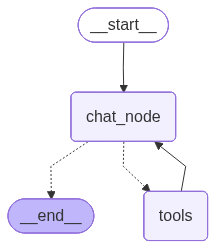

In [17]:
from IPython.display import Image, display
display(Image(chatbot.get_graph().draw_mermaid_png()))

In [18]:
config = {"configurable": {"thread_id": "thread_1"}}
while True:
    user_message = input("\nYour message : ")
    if user_message.strip().lower() in  ['exit','quit','bye']:
        initial_state = {
            'messages' : [HumanMessage(user_message)]
        }
        final_state = chatbot.invoke(initial_state, config=config)
        print("AI Message : ",final_state['messages'][-1].text)
        break
    initial_state = {
        'messages' : [HumanMessage(user_message)]
    }

    final_state = chatbot.invoke(initial_state, config=config)
    print("\nAI Message : ",final_state['messages'][-1].text)


Your message :  Hi my name is Bipulva



AI Message :  Hello Bipulva! How can I assist you today?



Your message :  What tools do you have currently?



AI Message :  I have several tools at my disposal to help with various tasks. Here are some of them:

- **Calculator**: Can evaluate basic mathematical expressions.
- **Web Search**: Can search the web for current events, facts, or information when I don't know the answer offhand.
- **Get Weather**: Provides the current weather for a specific city.
- **Add and Multiply**: Functions to perform addition and multiplication of numbers.
- **Get Current Time**: Returns the current date and time.

Let me know how you'd like to use any of these tools!



Your message :  tell me the current time. multiply the hours with seconds. you get the result. add the individual digits of the result. and then, give me the ascii character of the result obtained. then give me the latest AI news. also tell me about todays weather in bengaluru. 


...


AI Message :  The current weather in Bengaluru is cloudy with a temperature around 22°C. For today's detailed forecast, it appears that the temperature might reach up to 29.8°C during the day. The weather seems to be varying throughout the day, so staying updated with local forecasts would be beneficial.



Your message :  Can you find who is Devansh Soni from DTU through web search



AI Message :  Devansh Soni is a Computer Science & Engineering undergraduate at Delhi Technological University (DTU). He has an interest in building and tinkering with hardware and software. Devansh has contributed to both large and small-scale web applications, working as a Full Stack Developer using Agile methodologies.

He is active on various platforms:
- **GitHub**: Username `devanshsonii` with 18 repositories.
- **LinkedIn**: Has over 500 connections.
- **Facebook**: You can connect with him there.
- **Instagram**: Username `dtu_27244`.

If you need more specific information or updates, these platforms would be good places to look.



Your message :  bye


AI Message :  Goodbye! If you have any other questions in the future, feel free to reach out. Have a great day!
